## Combine BCalm results and metadata into the element annotation table

Builds one row per MPRA element with:
- [x] BCalm normalized activity (NGN2), significance, effect direction
- [x] SCREEN cCRE overlap: brain / heart / H1 (simple flag + per-class group: PLS, dELS, pELS, ...); WTC11 class groups too
- [x] TSS distance and closest gene (GENCODE v42)
- [x] gene association: gene name from header + gene_set membership
- [x] E2G enhancer-gene links: brain and cardiac cell types
- [x] NGN2/WTC11 ATAC-seq peak overlap
- [x] REMAP2022 TF binding site overlap: TF list, count, unique count
- [x] PhastCons100way conservation score
- [x] fine-mapped GTEx eQTL overlap (brain tissues), summarized per element
- [x] singleton variant density per element


In [1]:
import os
import re
import sys
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import requests
import yaml
from mygene import MyGeneInfo
from scipy.stats import mannwhitneyu

sys.path.append("../00_helpful_functions")
import helpful_functions as hf

# column names
col_name = "name"
col_header = "name"
col_sequence = "sequence"
col_category = "category"
col_class = "class"
col_source = "source"
col_ref = "ref"
col_chr = "chr"
col_start = "start"
col_end = "end"
col_strand = "strand"
col_variant_class = "variant_class"
col_variant_pos = "variant_pos"
col_SPDI = "SPDI"
col_allele = "allele"
col_info = "info"

list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

config_path = "data/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)

region_significant_level = 0.05
writing = False  # set True to (re)write intermediate BED files and the final output tables
plotting = False  # set True to also show the optional raw-activity QC plot


def generate_region_id(row, col_chr, col_start, col_end):
    """Format 'chr:start-end', using 'NA' for missing start/end."""
    chr_part = str(row[col_chr])
    start_part = str(int(row[col_start])) if not pd.isna(row[col_start]) else "NA"
    end_part = str(int(row[col_end])) if not pd.isna(row[col_end]) else "NA"
    return f"{chr_part}:{start_part}-{end_part}"


def normalize_name(name):
    """Sort ';'-joined header parts so BCalm/metadata/label names line up regardless of allele order."""
    parts = sorted(part.strip() for part in name.split(";"))
    return ";".join(sorted(parts, reverse=True))

## Load metadata and BCalm element activity

In [2]:
bcalm_element_results_path = config["files"]["creating"][
    "NGN2_2511_element_activity_dna_>=1_bcalm_normalized_scrambled_ctrl"
]
mpra_80k_metadata_path = config["files"]["creating"][
    "MPRA_251117_corrected_spdi"
]

labelfile_path = config["files"]["creating"][
    "80k_label_file"
]

mpra_80k_metadata_df = pd.read_csv(
    mpra_80k_metadata_path, sep="\t", compression="gzip", low_memory=False
)
for col in list_columns:
    mpra_80k_metadata_df[col] = mpra_80k_metadata_df[col].apply(hf.safe_eval)

mpra_80k_metadata_df["normalized_name"] = mpra_80k_metadata_df[col_name].apply(
    normalize_name
)

In [3]:
bcalm_element_df = pd.read_csv(bcalm_element_results_path, sep="\t")
label_file_df = pd.read_csv(
    labelfile_path, sep="\t", header=None, names=["name", "label"]
)
bcalm_element_df = bcalm_element_df.merge(label_file_df, on="name", how="left")
print(f"BCalm rows missing a label: {bcalm_element_df['label'].isna().sum()}")
bcalm_element_df["label"].value_counts()

BCalm rows missing a label: 0


label
cardiac_neuro_cava_random            65308
MK                                    1586
C_positive_heart_AB                    605
scramble_ctrl                          474
GC_Selvarajan                          311
negative_neuron_ctrl                   271
GC_Vista                               227
GC_Mendelian_variants                  199
GC_Kircher                             189
GC_Cort_Chengyu                        185
C_negative_heart_MK                    185
C_SLEA                                 174
C_positive_neuron_MK                    94
C_positive_heart_CAD                    90
C_positive_heart_MK                     83
GC_Glut_Chengyu                         83
C_positive_neuron_NP                    68
C_positive_neuron_CD                    67
GC_DNase_positive_shuffeled             51
GC_Atrial_fib                           43
GC_DNase_positive                       38
GC_GABA_Chengyu                         35
GC_Mohlke                               33
GC_DN

In [4]:
def apply_custom_scrambled_normalization(df_celltype, raw_activity_col, label_col="label"):
    """Normalize activities using the median/std of scrambled controls."""
    scrambled_controls = df_celltype.loc[
        df_celltype[label_col] == "scramble_ctrl", raw_activity_col
    ].dropna()
    if scrambled_controls.empty:
        raise ValueError(
            f"No scrambled control values found for '{raw_activity_col}'."
        )

    scrambled_median = scrambled_controls.median()
    scrambled_std = scrambled_controls.std()
    if scrambled_std == 0:
        print(
            f"Warning: scrambled std is zero for {raw_activity_col}; normalizing by subtraction only."
        )
        normalized = df_celltype[raw_activity_col] - scrambled_median
    else:
        normalized = (df_celltype[raw_activity_col] - scrambled_median) / scrambled_std
    return normalized, scrambled_median, scrambled_std


(
    bcalm_element_df["normalized_activity_NGN2"],
    ngn2_scrambled_median,
    ngn2_scrambled_std,
) = apply_custom_scrambled_normalization(bcalm_element_df, "logFC")
print(
    f"NGN2 scrambled median: {ngn2_scrambled_median:.4f}, std: {ngn2_scrambled_std:.4f}"
)

bcalm_element_df["significant_region_NGN2"] = (
    bcalm_element_df["adj.P.Val"] < region_significant_level
)

# effect direction
def set_effect_direction(
    row,
    logfc_col="normalized_activity_NGN2",
    significant_col="different_active_to_scrambled",
):
    if pd.isna(row[logfc_col]):
        return "no_readout"
    # if significant
    elif row[significant_col]:
        if row[logfc_col] > 0:
            return "increasing"
        elif row[logfc_col] < 0:
            return "decreasing"
        else:
            return "neutral"
    else:
        return "not_significant"


bcalm_element_df["effect_direction_NGN2"] = (
    bcalm_element_df.apply(
        set_effect_direction,
        logfc_col="normalized_activity_NGN2",
        significant_col="significant_region_NGN2",
        axis=1,
    )
)


bcalm_element_df["normalized_name"] = bcalm_element_df["name"].apply(normalize_name)

bcalm_columns_of_interest = [
    "normalized_name",
    "logFC",
    "adj.P.Val",
    "normalized_activity_NGN2",
    "significant_region_NGN2",
    "effect_direction_NGN2",
]

NGN2 scrambled median: -0.0680, std: 0.3858


#### Normalized and not-normalized activity distribution

/tmp/ipykernel_101393/824961420.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


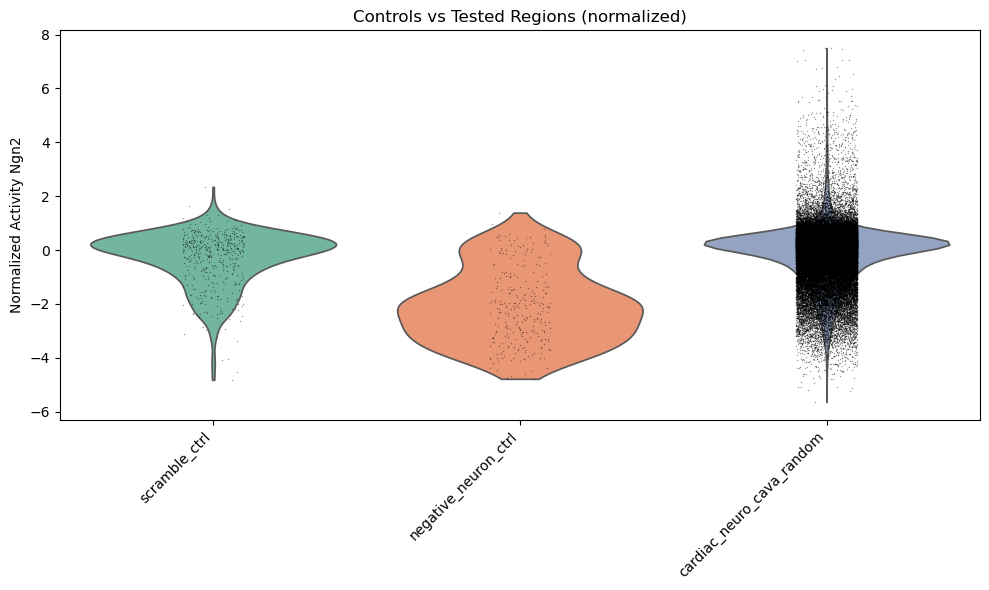

In [5]:
def plot_activity_by_label(
    df,
    value_col="normalized_activity_NGN2",
    label_col="label",
    labels_to_include=None,
    order=None,
    title="Region Activity by Label",
    show_points=False,
    figsize=(10, 6),
    palette="Set2",
):
    """Violin plot of the activity distribution for selected label groups."""
    plot_df = df if labels_to_include is None else df[df[label_col].isin(labels_to_include)]

    plt.figure(figsize=figsize)
    sns.violinplot(
        data=plot_df, x=label_col, y=value_col, order=order, palette=palette, cut=0, inner=None
    )
    if show_points:
        sns.stripplot(
            data=plot_df, x=label_col, y=value_col, order=order, color="black", size=1, alpha=0.4
        )
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel(value_col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


controls = ["scramble_ctrl", "negative_neuron_ctrl"]
tested = ["cardiac_neuro_cava_random"]

if plotting:
    plot_activity_by_label(
        bcalm_element_df,
        value_col="logFC",
        labels_to_include=controls + tested,
        order=controls + tested,
        title="Controls vs Tested Regions (raw logFC)",
        show_points=True,
    )

plot_activity_by_label(
    bcalm_element_df,
    value_col="normalized_activity_NGN2",
    labels_to_include=controls + tested,
    order=controls + tested,
    title="Controls vs Tested Regions (normalized)",
    show_points=True,
)

In [6]:
mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df.merge(
    bcalm_element_df[bcalm_columns_of_interest], on="normalized_name", how="left"
)
print(
    f"Elements with a BCalm readout: {mpra_80k_metadata_df_bcalm['logFC'].notna().sum()}"
)

mpra_80k_metadata_df_bcalm["region_info"] = mpra_80k_metadata_df_bcalm.apply(
    lambda row: generate_region_id(row, col_chr, col_start, col_end), axis=1
)

Elements with a BCalm readout: 70479


In [7]:
# region_info + a BED of unique regions, used as the `-a` input for the external
# bedtools TSS-distance and E2G-overlap steps below (bedtools commands noted at each step).
mpra_80k_unique_regions = mpra_80k_metadata_df_bcalm.drop_duplicates(
    subset=[col_chr, col_start, col_end]
)
mpra_80k_unique_regions_no_missing = mpra_80k_unique_regions.dropna(
    subset=[col_chr, col_start, col_end]
).copy()
mpra_80k_unique_regions_no_missing[col_start] = mpra_80k_unique_regions_no_missing[
    col_start
].astype(int)
mpra_80k_unique_regions_no_missing[col_end] = mpra_80k_unique_regions_no_missing[
    col_end
].astype(int)

unique_regions_bed_path = (
    "data/mpra_80k_unique_regions.bed"
)
columns_for_bed = [col_chr, col_start, col_end, col_name]
if writing:
    mpra_80k_unique_regions_no_missing.sort_values(by=[col_chr, col_start, col_end])[
        columns_for_bed
    ].to_csv(unique_regions_bed_path, sep="\t", index=False, header=False)
    print(f"Wrote BED file to {unique_regions_bed_path}")

### E2G overlap
Enhancer-gene predictions, aggregated per element; also gives the gene used for the
TSS-distance computation below.

In [8]:
def combine_e2g_predictions(e2g_bedpe_paths):
    """Read + concatenate per-cell-type E2G bedpe files, tagging each row's source."""
    e2g_dfs = []
    for cell_type, path in e2g_bedpe_paths.items():
        e2g_df = pd.read_csv(path, sep="\t", low_memory=False, header=None)
        e2g_df.columns = [
            "tmp_e2g_enhancer_chr",
            "tmp_e2g_enhancer_start",
            "tmp_e2g_enhancer_end",
            "tmp_e2g_gene_TSS_chr",
            "tmp_e2g_gene_TSS_start",
            "tmp_e2g_gene_TSS_end",
            "tmp_e2g_gene_name_range",
            "tmp_e2g_score",
            "tmp_e2g_enhancer_strand",
            "tmp_e2g_gene_strand",
        ]
        e2g_df["source"] = cell_type + "|" + e2g_df["tmp_e2g_gene_name_range"]
        e2g_dfs.append(e2g_df)
    return pd.concat(e2g_dfs, ignore_index=True)


def extract_cell_type_and_gene(e2g_gene_name_range):
    """'ecto_neural_progenitor_cell|FAAP20|chr1:2194354-2195958' -> (cell_type, gene)."""
    parts = e2g_gene_name_range.split("|")
    if len(parts) >= 2:
        return parts[0], parts[1]
    return None, None


def calculate_e2g_distance_to_TSS(row):
    """Distance from element to nearest TSS edge; 0 if the element overlaps the TSS."""
    element_start, element_end = row["element_start"], row["element_end"]
    tss_start, tss_end = row["e2g_gene_TSS_start"], row["e2g_gene_TSS_end"]
    if element_end < tss_start:
        return min(tss_start - element_end, tss_start - element_start)
    if element_start > tss_end:
        return min(element_start - tss_end, element_end - tss_end)
    return 0


def aggregate_e2g_overlap(e2g_overlap_bed_path, prefix):
    """Aggregate a bedtools-intersect output (element x E2G enhancer) to one row per element."""
    e2g_overlap_df = pd.read_csv(e2g_overlap_bed_path, sep="\t", header=None)
    e2g_overlap_df.columns = [
        "element_chr",
        "element_start",
        "element_end",
        "element_name",
        "e2g_enhancer_chr",
        "e2g_enhancer_start",
        "e2g_enhancer_end",
        "e2g_gene_TSS_chr",
        "e2g_gene_TSS_start",
        "e2g_gene_TSS_end",
        "e2g_gene_name_range",
        "e2g_score",
        "e2g_enhancer_strand",
        "e2g_gene_strand",
    ]
    e2g_overlap_df[["e2g_cell_type", "e2g_gene_name"]] = e2g_overlap_df[
        "e2g_gene_name_range"
    ].apply(lambda x: pd.Series(extract_cell_type_and_gene(x)))
    e2g_overlap_df["e2g_distance_to_TSS"] = e2g_overlap_df.apply(
        calculate_e2g_distance_to_TSS, axis=1
    )

    e2g_columns_of_interest = [
        "element_chr",
        "element_start",
        "element_end",
        "element_name",
        "e2g_cell_type",
        "e2g_gene_name",
        "e2g_score",
        "e2g_distance_to_TSS",
    ]
    e2g_aggregated = (
        e2g_overlap_df[e2g_columns_of_interest]
        .groupby(["element_chr", "element_start", "element_end", "element_name"])
        .agg(
            e2g_cell_type=("e2g_cell_type", lambda x: ";".join(sorted(x.unique()))),
            e2g_gene_name=("e2g_gene_name", lambda x: ";".join(sorted(x.unique()))),
            e2g_score=("e2g_score", lambda x: ";".join(map(str, sorted(x.unique())))),
            e2g_distance_to_TSS=(
                "e2g_distance_to_TSS",
                lambda x: ";".join(map(str, sorted(x.unique()))),
            ),
        )
        .reset_index()
    )
    e2g_aggregated["region_info"] = e2g_aggregated.apply(
        lambda row: generate_region_id(row, "element_chr", "element_start", "element_end"),
        axis=1,
    )
    return e2g_aggregated.rename(
        columns={
            "e2g_cell_type": f"{prefix}_e2g_cell_type",
            "e2g_gene_name": f"{prefix}_e2g_gene_name",
            "e2g_score": f"{prefix}_e2g_score",
            "e2g_distance_to_TSS": f"{prefix}_e2g_distance_to_TSS",
        }
    )


e2g_combined_bed_columns = [
    "tmp_e2g_enhancer_chr",
    "tmp_e2g_enhancer_start",
    "tmp_e2g_enhancer_end",
    "tmp_e2g_gene_TSS_chr",
    "tmp_e2g_gene_TSS_start",
    "tmp_e2g_gene_TSS_end",
    "source",
    "tmp_e2g_score",
    "tmp_e2g_enhancer_strand",
    "tmp_e2g_gene_strand",
]

#### Brain

In [9]:
e2g_brain_bedpe_paths = {
    "ecto_neural_progenitor_cell": "data/e2g/encode_e2g_predictions_ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI_DNaseOnly_thresholded_predictions.bedpe.gz",
    "neural_progenitor_cell": "data/e2g/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz",
    "neuronal_stem_cell": "data/e2g/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz",
    "brain_ENCDO708OLI_ENCFF425GUX": "data/e2g/encode_e2g_predictions_brain_ENCDO708OLI_ENCFF425GUX_DNaseOnly_thresholded_predictions.bedpe.gz",
    "brain_pericyte": "data/e2g/encode_e2g_predictions_brain_pericyte_ENCDO228AAA_ENCFF582YGW_DNaseOnly_thresholded_predictions.bedpe.gz",
    "midbrain_ENCDO240JUB_ENCFF325QQS": "data/e2g/encode_e2g_predictions_midbrain_ENCDO240JUB_ENCFF325QQS_DNaseOnly_thresholded_predictions.bedpe.gz",
    "brain_microvascular_endothelial_cell": "data/e2g/encode_e2g_predictions_brain_microvascular_endothelial_cell_ENCDO227AAA_ENCFF203RLS_DNaseOnly_thresholded_predictions.bedpe.gz",
}

e2g_brain_combined = combine_e2g_predictions(e2g_brain_bedpe_paths)
e2g_brain_combined_path = "data/e2g/combined_e2g_predictions_NSC_NPC_ecto_neuron_brain_brain_microvascular_pericyte_midbrain.bedpe.gz"
if writing:
    e2g_brain_combined[e2g_combined_bed_columns].to_csv(
        e2g_brain_combined_path, sep="\t", index=False, header=False, compression="gzip"
    )
    print(f"Wrote combined brain E2G predictions to {e2g_brain_combined_path}")

# bedtools intersect -wa -wb -f 0.6 \
#   -a data/mpra_80k_unique_regions.bed \
#   -b {e2g_brain_combined_path} \
#   > data/e2g/intersected_80k_all_unique_not_missing_regions_with_e2g_predictions_NSC_NPC_ecto_neuron_brain_brain_microvascular_pericyte_midbrain.bed

In [10]:
e2g_brain_overlap_bed_path = "data/e2g/intersected_80k_all_unique_not_missing_regions_with_e2g_predictions_NSC_NPC_ecto_neuron_brain_brain_microvascular_pericyte_midbrain.bed"
e2g_brain_aggregated = aggregate_e2g_overlap(e2g_brain_overlap_bed_path, prefix="brain")

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    e2g_brain_aggregated.drop(
        columns=["element_chr", "element_start", "element_end", "element_name"]
    ),
    on="region_info",
    how="left",
)
print(
    f"Elements with a brain E2G gene link: {mpra_80k_metadata_df_bcalm['brain_e2g_gene_name'].notna().sum()}"
)

Elements with a brain E2G gene link: 15292


#### Heart

In [11]:
e2g_cardiac_bedpe_paths = {
    "Right_ventricle_myocardium_inferior": "data/e2g/encode_e2g_predictions_Right_ventricle_myocardium_inferior_ENCDO520EJG_ENCFF353FPQ_DNaseOnly_thresholded_predictions.bedpe.gz",
    "Right_ventricle_myocardium_superior": "data/e2g/encode_e2g_predictions_Right_ventricle_myocardium_superior_ENCDO520EJG_ENCFF710GZI_DNaseOnly_thresholded_predictions.bedpe.gz",
    "cardiac_fibroblast": "data/e2g/encode_e2g_predictions_cardiac_fibroblast_ENCDO095AAA_ENCFF175BFW_DNaseOnly_thresholded_predictions.bedpe.gz",
    "cardiac_muscle_cell": "data/e2g/encode_e2g_predictions_cardiac_muscle_cell_ENCDO221AAA_ENCFF062FBQ_DNaseOnly_thresholded_predictions.bedpe.gz",
    "cardiac_myoblast": "data/e2g/encode_e2g_predictions_cardiac_myoblast_ENCDO221AAA_ENCFF426WHF_DNaseOnly_thresholded_predictions.bedpe.gz",
    "cardiac_septum": "data/e2g/encode_e2g_predictions_cardiac_septum_ENCDO575WHY_ENCFF478AUS_DNaseOnly_thresholded_predictions.bedpe.gz",
    "cardiovascular_progenitor_cell": "data/e2g/encode_e2g_predictions_cardiovascular_progenitor_cell_ENCDO221AAA_ENCFF043LBC_DNaseOnly_thresholded_predictions.bedpe.gz",
    "left_cardiac_atrium": "data/e2g/encode_e2g_predictions_left_cardiac_atrium_ENCDO856ZOJ_ENCFF857BLF_DNaseOnly_thresholded_predictions.bedpe.gz",
    "left_ventricle_myocardium_inferior": "data/e2g/encode_e2g_predictions_left_ventricle_myocardium_inferior_ENCDO520EJG_ENCFF616QAS_DNaseOnly_thresholded_predictions.bedpe.gz",
    "left_ventricle_myocardium_superior": "data/e2g/encode_e2g_predictions_left_ventricle_myocardium_superior_ENCDO520EJG_ENCFF153TBA_DNaseOnly_thresholded_predictions.bedpe.gz",
    "mesothelial_cell_of_epicardium": "data/e2g/encode_e2g_predictions_mesothelial_cell_of_epicardium_ENCDO222AAA_ENCFF139MJE_DNaseOnly_thresholded_predictions.bedpe.gz",
    "right_cardiac_atrium": "data/e2g/encode_e2g_predictions_right_cardiac_atrium_ENCDO520EJG_ENCFF104IKA_DNaseOnly_thresholded_predictions.bedpe.gz",
    "smooth_muscle_cell_of_the_brain_vasculature": "data/e2g/encode_e2g_predictions_smooth_muscle_cell_of_the_brain_vasculature_ENCDO229AAA_ENCFF664RKN_DNaseOnly_thresholded_predictions.bedpe.gz",
}

e2g_cardiac_combined = combine_e2g_predictions(e2g_cardiac_bedpe_paths)
e2g_cardiac_combined_path = "data/e2g/combined_e2g_predictions_ventricle_myocardium_cardiac_fibroblast_muscle_cell_myoblast_septum_CPC.bedpe.gz"
if writing:
    e2g_cardiac_combined[e2g_combined_bed_columns].to_csv(
        e2g_cardiac_combined_path, sep="\t", index=False, header=False, compression="gzip"
    )
    print(f"Wrote combined cardiac E2G predictions to {e2g_cardiac_combined_path}")

# bedtools intersect -wa -wb -f 0.6 \
#   -a data/e2g/mpra_80k_unique_regions.bed \
#   -b {e2g_cardiac_combined_path} \
#   > intersected_80k_all_unique_e2g_predictions_ventricle_myocardium_cardiac_fibroblast_muscle_cell_myoblast_septum_CPC.bed

In [12]:
e2g_cardiac_overlap_bed_path = "data/e2g/intersected_80k_all_unique_e2g_predictions_ventricle_myocardium_cardiac_fibroblast_muscle_cell_myoblast_septum_CPC.bed"
e2g_cardiac_aggregated = aggregate_e2g_overlap(e2g_cardiac_overlap_bed_path, prefix="cardiac")

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    e2g_cardiac_aggregated.drop(
        columns=["element_chr", "element_start", "element_end", "element_name"]
    ),
    on="region_info",
    how="left",
)
print(
    f"Elements with a cardiac E2G gene link: {mpra_80k_metadata_df_bcalm['cardiac_e2g_gene_name'].notna().sum()}"
)

Elements with a cardiac E2G gene link: 14663


### TSS distance
`bedtools closest -a mpra_80k_unique_regions.bed -b gencode_v42_tss_sorted.bed.gz -d | gzip > 80k_all_unique_not_missing_regions_tss_distances.bed.gz`

In [13]:
# # note the gencode information needs to be downloaded from the gencode website `https://www.gencodegenes.org/human/release_42.html`

# # Extract TSSs from GTF (example for gene features)
# # This command extracts the gene start for + strand and gene end for - strand as the TSS.
# # It creates a BED-like file (chr, TSS-1, TSS, gene_id, score, strand)
# awk '$3 == "gene" {
#     if ($7 == "+") print $1 "\t" $4-1 "\t" $4 "\t" $10 "\t" ".\t" $7;
#     else if ($7 == "-") print $1 "\t" $5-1 "\t" $5 "\t" $10 "\t" ".\t" $7;
# }' <( zcat data/gencode.v42.annotation.gtf.gz ) > data/gencode_v42_tss.bed

# # Sort the TSS file (important for bedtools efficiency)
# sort -k1,1 -k2,2n data/gencode_v42_tss.bed > data/gencode_v42_tss_sorted.bed

# rm data/gencode_v42_tss.bed
# gzip data/gencode_v42_tss_sorted.bed

# bedtools closest -a data/mpra_80k_unique_regions.bed -b data/gencode_v42_tss_sorted.bed.gz -d | gzip > data/80k_all_unique_not_missing_regions_tss_distances.bed.gz

In [15]:
gene_annotation_path = "data/gencode.v42.gtf.gz"
tss_distances_bed_path = "data/80k_all_unique_not_missing_regions_tss_distances.bed.gz"

distances_to_tss_df = pd.read_csv(tss_distances_bed_path, sep="\t", header=None)
distances_to_tss_df.columns = [
    "chrom",
    "start",
    "end",
    "cre_id",
    "chrom_tss",
    "chrom_tss_start",
    "chrom_tss_end",
    "gene_id",
    "tss_score",
    "tss_strand",
    "tss_distance",
]
distances_to_tss_df["gene_id"] = distances_to_tss_df["gene_id"].str.rstrip(";")
distances_to_tss_df["region_info"] = distances_to_tss_df.apply(
    lambda row: generate_region_id(row, "chrom", "start", "end"), axis=1
)
# keep only the closest TSS per region
distances_to_tss_df = distances_to_tss_df.sort_values("tss_distance").drop_duplicates(
    subset=["region_info"], keep="first"
)

# annotate with the gene name
gene_annotations_df = pd.read_csv(gene_annotation_path, sep="\t", comment="#", header=None)
gene_annotations_df.columns = [
    "chrom",
    "source",
    "feature",
    "start",
    "end",
    "score",
    "strand",
    "frame",
    "attribute",
]
gene_only_annotations_df = gene_annotations_df.loc[
    gene_annotations_df["feature"] == "gene"
].copy()


def extract_gene_id(attribute):
    for item in attribute.split(";"):
        item = item.strip()
        if item.startswith("gene_id"):
            return item.split(" ")[1].replace('"', "")
    return None


def extract_gene_name(attribute):
    for item in attribute.split(";"):
        item = item.strip()
        if item.startswith("gene_name"):
            return item.split(" ")[1].replace('"', "")
    return None


gene_only_annotations_df["gene_id"] = gene_only_annotations_df["attribute"].apply(
    extract_gene_id
)
gene_only_annotations_df["closest_tss_gene_name"] = gene_only_annotations_df[
    "attribute"
].apply(extract_gene_name)

distances_to_tss_df_with_gene_info = distances_to_tss_df.merge(
    gene_only_annotations_df[["gene_id", "closest_tss_gene_name"]], on="gene_id", how="left"
)

tss_info_columns = ["region_info", "gene_id", "closest_tss_gene_name", "tss_distance"]
mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    distances_to_tss_df_with_gene_info[tss_info_columns], on="region_info", how="left"
)
print(
    f"Elements with a TSS distance: {mpra_80k_metadata_df_bcalm['tss_distance'].notna().sum()}"
)

Elements with a TSS distance: 77870


### Add gene info to the tested regions

In [16]:
def get_gene_lookup_dict(gene_lists, gene_list_dir):
    """gene_name -> list of gene_set names it belongs to, one file per gene set."""
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file)) as f:
            gene_list_name = file.split(".")[0]
            for gene in f.read().splitlines():
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict


gene_list_dir = "data/gene_lists"
gene_lists = [f for f in os.listdir(gene_list_dir) if f.endswith(".txt")]
gene_lookup_dict = get_gene_lookup_dict(gene_lists, gene_list_dir)

mpra_80k_metadata_df_bcalm["gene_name"] = mpra_80k_metadata_df_bcalm["name"].apply(
    hf.get_gene_name
)
mpra_80k_metadata_df_bcalm["gene_set"] = mpra_80k_metadata_df_bcalm["gene_name"].apply(
    lambda gene: gene_lookup_dict[gene]
)
mpra_80k_metadata_df_bcalm["gene_set"].value_counts()

gene_set
[neuro]                   35550
[cardiac]                 21153
[cava]                     8699
[]                         6275
[random]                   4716
[neuro, cardiac]           2246
[neuro, cava]               859
[cava, cardiac]             514
[neuro, cava, cardiac]      203
Name: count, dtype: int64

In [ ]:
asdf

In [17]:
mpra_80k_metadata_df_bcalm.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'gene_name',
 'gene_set']

In [18]:
mpra_80k_metadata_df_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,brain_e2g_distance_to_TSS,cardiac_e2g_cell_type,cardiac_e2g_gene_name,cardiac_e2g_score,cardiac_e2g_distance_to_TSS,gene_id,closest_tss_gene_name,tss_distance,gene_name,gene_set
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,2276.0,SKI,[neuro]
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,1680.0,SKI,[neuro]
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,1289.0,SKI,[neuro]
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,639.0,SKI,[neuro]
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,4001.0,SKI,[neuro]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244322.0,116244591.0,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not given - control sequence,[]
80211,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374617.0,2374886.0,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not given - control sequence,[]
80212,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181691.0,71181960.0,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not given - control sequence,[]
80213,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031618.0,67031887.0,+,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not given - control sequence,[]


### Preprocess the SCREEN cCREs

In [ ]:
# # correctify the screen all CREs bed:
# # NOTE: the GRCh38-cCREs.bed.gz file is from SCREEN (https://screen.encodeproject.org/), downloaded 2024-06-05
# all_screen_cre_bed_path = "data/GRCh38-cCREs.bed.gz"
# all_screen_cre_bed = pd.read_csv(all_screen_cre_bed_path, sep="\t", header=None)
# all_screen_cre_bed.columns = ['chrom', 'start', 'end', 'name', 'another_name', 'annotation']
# all_screen_cre_bed

# all_screen_cre_bed['score'] = 0
# all_screen_cre_bed['strand'] = '+'

# # remove the chromosome prefix:
# all_screen_cre_bed['chr'] = all_screen_cre_bed['chrom'].apply(lambda x: x.replace('chr', ''))
# all_screen_cre_bed

# output_path_all_screen_cre_bed_no_chr = "data/all_SCREEN_GRCh38-cCREs_without_chr.bed.gz"
# write_output=False
# if write_output:
#     all_screen_cre_bed[['chr', 'start', 'end', 'name', 'score', 'strand']].to_csv(output_path_all_screen_cre_bed_no_chr, sep="\t", header=False, index=False, compression='gzip')

### Overlapping NGN2 ATAC data
`bedtools intersect -a data/reference_tested_genomic_SCREEN_regions.bed -b wtc11_ngn2_atac_peak_sorted.bed -f 0.3 > reference_sequence_overlap_atac_wtc11_ngn2.bed`

In [ ]:
NGN2_element_activity_tested = mpra_80k_metadata_df_bcalm.loc[(mpra_80k_metadata_df_bcalm['normalized_activity_NGN2'].notnull()) & (mpra_80k_metadata_df_bcalm['name'].str.contains("cardiac_neuro_cava_random"))].copy()
# Consider only Reference sequences:
NGN2_natural_CREs_tested = NGN2_element_activity_tested.loc[~NGN2_element_activity_tested['name'].str.contains("ALT_")]

NGN2_natural_CREs_tested_dedup = NGN2_natural_CREs_tested.drop_duplicates(subset=['chr', 'start', 'end']).copy()
NGN2_natural_CREs_tested_dedup['start'] = NGN2_natural_CREs_tested_dedup['start'].astype(int)
NGN2_natural_CREs_tested_dedup['end'] = NGN2_natural_CREs_tested_dedup['end'].astype(int)

open_ngn2_atac_peaks = pd.read_csv("data/DIV14_WTC11-NGN2_ExN_ATAC-seq.idr0.05.bfilt.narrowPeak", sep="\t", header=None)
open_ngn2_atac_peaks # chrom, start, end name, score

write_output = False
if write_output:
    screen_region_output = "data/reference_tested_genomic_SCREEN_regions.bed"
    NGN2_natural_CREs_tested_dedup[['chr', 'start', 'end', 'name']].to_csv(screen_region_output, sep="\t", index=False, header=False)

    open_ngn2_atac_peaks[open_ngn2_atac_peaks.columns[0:3]].to_csv('data/wtc11_ngn2_atac_peak.bed', sep="\t", header=None, index=False)

In [20]:
NGN2_natural_CREs_tested_dedup

,name,sequence,category,class,source,ref,chr,start,end,strand,...,brain_e2g_distance_to_TSS,cardiac_e2g_cell_type,cardiac_e2g_gene_name,cardiac_e2g_score,cardiac_e2g_distance_to_TSS,gene_id,closest_tss_gene_name,tss_distance,gene_name,gene_set
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,2276.0,SKI,[neuro]
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,1680.0,SKI,[neuro]
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,4001.0,SKI,[neuro]
5,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000182873.5,PRKCZ-AS1,8248.0,SKI,[neuro]
7,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,NaN,NaN,NaN,NaN,NaN,ENSG00000234396.3,ENSG00000234396,8873.0,SKI,[neuro]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27559,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,NaN,NaN,NaN,NaN,NaN,ENSG00000071889.17,FAM3A,3225.0,G6PD,[cava]
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,7693,NaN,NaN,NaN,NaN,ENSG00000269335.7,IKBKG,1874.0,G6PD,[cava]
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,NaN,NaN,NaN,NaN,NaN,ENSG00000160211.20,G6PD,2302.0,G6PD,[cava]
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,NaN,NaN,NaN,NaN,NaN,ENSG00000160211.20,G6PD,2231.0,G6PD,[cava]


In [ ]:
reference_atac_ngn2_overlap_path = "data/reference_sequence_overlap_atac_wtc11_ngn2.bed.gz"

mpra_80k_metadata_df_bcalm["SCREEN_ID"] = mpra_80k_metadata_df_bcalm["name"].apply(
    hf.extract_eh38e_number
)

reference_atac_ngn2_overlap_df = pd.read_csv(
    reference_atac_ngn2_overlap_path,
    sep="\t",
    header=None,
    names=["chr", "start", "end", "name"],
)
reference_atac_ngn2_overlap_df["SCREEN_ID"] = reference_atac_ngn2_overlap_df["name"].apply(
    hf.extract_eh38e_number
)
reference_atac_ngn2_overlap_df["is_ngn2_atac_overlap"] = True
reference_atac_ngn2_overlap_df = reference_atac_ngn2_overlap_df.drop_duplicates(
    subset=["SCREEN_ID"]
)

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    reference_atac_ngn2_overlap_df[["SCREEN_ID", "is_ngn2_atac_overlap"]],
    on="SCREEN_ID",
    how="left",
)
mpra_80k_metadata_df_bcalm["is_ngn2_atac_overlap"] = mpra_80k_metadata_df_bcalm[
    "is_ngn2_atac_overlap"
].fillna(False)

/tmp/ipykernel_98414/1133542131.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)


### SCREEN CREs annotation
- [x] Brain
- [x] heart
- [x] h1 stem cells

In [ ]:
def add_SCREEN_CRE_info(df, config_info, new_name, screen_id_col="SCREEN_ID"):
    """Flag whether an element's SCREEN_ID is an active cCRE in the given tissue bed."""
    screen_regions = pd.read_csv(config["files"]["creating"][config_info], sep="\t")
    screen_regions.columns = [
        "chr",
        "start",
        "end",
        screen_id_col,
        "score",
        "strand",
        "second_start",
        "second_end",
        "intensity",
        "annotation",
        "info",
    ]
    screen_regions[new_name] = True
    df = df.merge(screen_regions[[screen_id_col, new_name]], on=screen_id_col, how="left")
    df[new_name] = df[new_name].astype("boolean").fillna(False)
    return df


def add_SCREEN_CRE_annotation_group_info(df, config_info, new_name, screen_id_col="SCREEN_ID"):
    """Flag each cCRE class (PLS, dELS, pELS, ...) separately, e.g. is_NPC_SCREEN_pELS."""
    screen_regions = pd.read_csv(config["files"]["creating"][config_info], sep="\t")
    screen_regions.columns = [
        "chr",
        "start",
        "end",
        screen_id_col,
        "score",
        "strand",
        "second_start",
        "second_end",
        "intensity",
        "annotation",
        "info",
    ]
    for group_name in screen_regions["annotation"].unique():
        new_col_name = f"{group_name}_{new_name}"
        screen_regions_group = screen_regions.loc[
            screen_regions["annotation"] == group_name, [screen_id_col]
        ].copy()
        screen_regions_group[new_col_name] = True
        df = df.merge(screen_regions_group, on=screen_id_col, how="left")
        df[new_col_name] = df[new_col_name].astype("boolean").fillna(False)
    return df


mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_info(
    mpra_80k_metadata_df_bcalm, "brain_screen_active_cre", "is_brain_SCREEN_cCRE"
)
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_info(
    mpra_80k_metadata_df_bcalm, "heart_screen_active_cre", "is_heart_SCREEN_cCRE"
)
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_info(
    mpra_80k_metadata_df_bcalm, "H1_screen_active_cre", "is_H1_SCREEN_cCRE"
)

In [ ]:
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_annotation_group_info(
    mpra_80k_metadata_df_bcalm, "brain_screen_active_cre", "is_brain_SCREEN_cCRE_group"
)
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_annotation_group_info(
    mpra_80k_metadata_df_bcalm, "heart_screen_active_cre", "is_heart_SCREEN_cCRE_group"
)
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_annotation_group_info(
    mpra_80k_metadata_df_bcalm, "H1_screen_active_cre", "is_H1_SCREEN_cCRE_group"
)
mpra_80k_metadata_df_bcalm = add_SCREEN_CRE_annotation_group_info(
    mpra_80k_metadata_df_bcalm, "WTC11_screen_active_cre", "is_WTC11_SCREEN_cCRE_group"
)
print(
    f"Elements with a SCREEN_ID: {mpra_80k_metadata_df_bcalm['SCREEN_ID'].notna().sum()}"
)

Elements with a SCREEN_ID: 73944


### Add eQTL information
Fine-mapped GTEx eQTLs from neuron-related tissues only, summarized per element.

In [ ]:
brain_tissues = [
    "Brain_Amygdala",
    "Brain_Anterior_cingulate_cortex_BA24",
    "Brain_Caudate_basal_ganglia",
    "Brain_Cerebellar_Hemisphere",
    "Brain_Cerebellum",
    "Brain_Cortex",
    "Brain_Frontal_Cortex_BA9",
    "Brain_Hippocampus",
    "Brain_Hypothalamus",
    "Brain_Nucleus_accumbens_basal_ganglia",
    "Brain_Putamen_basal_ganglia",
    "Brain_Spinal_cord_cervical_c-1",
    "Brain_Substantia_nigra",
]


def _parse_variant_hg38_to_coords(variant_hg38):
    """
    Parse GTEx 'variant_hg38' into (chrom, start0, end0, ref, alt).
    Accepts 'chr1_13550_G_A_b38' or 'chr1:13550:G:A'.
    POS is 1-based in the input; returned start/end are 0-based half-open.
    """
    if pd.isna(variant_hg38):
        return None
    s = re.sub(r"[_:-]?b38$", "", str(variant_hg38).strip()).replace(":", "_")
    parts = s.split("_")
    if len(parts) < 4:
        return None
    chrom, pos_str, ref, alt = parts[0], parts[1], parts[2], parts[3]
    try:
        pos = int(pos_str)
    except ValueError:
        return None
    start0 = pos - 1
    end0 = start0 + max(1, len(ref))
    return chrom, start0, end0, ref, alt


def _ensembl_batch_lookup(ensembl_ids, batch_size=1000, sleep_time=0.2):
    """Batch lookup Ensembl gene IDs via REST API for symbols MyGeneInfo missed."""
    base_url = "https://rest.ensembl.org/lookup/id"
    mapping = {}
    for i in range(0, len(ensembl_ids), batch_size):
        batch = ensembl_ids[i : i + batch_size]
        try:
            r = requests.post(
                base_url, headers={"Content-Type": "application/json"}, json={"ids": batch}, timeout=30
            )
            if r.ok:
                for k, v in r.json().items():
                    if v and "display_name" in v:
                        mapping[k] = v["display_name"]
        except Exception:
            pass
        time.sleep(sleep_time)
    return mapping


def annotate_mpra_with_eqtls(
    mpra_df,
    eqtl_path,
    tissues,
    mpra_chrom_col="chr",
    mpra_start_col="start",
    mpra_end_col="end",
    eqtl_tissue_col="tissue",
    eqtl_gene_col="gene",
    eqtl_pip_col="pip",
    eqtl_variant_col="variant_hg38",
    eqtl_beta_col="beta_posterior",
    pip_threshold=0.9,
    chunksize=5_000_000,
    out_gene_symbol_col="eqtl_gene_symbol",
    out_status_col="eqtl_annotation_status",
    out_significant_col="is_significant_eqtl",
    out_eqtl_beta_col="eqtl_effect_size_linear_model",
    out_eqtl_pip_col="eqtl_pip",
    out_eqtl_gene_col="eqtl_gene_ensembl_id",
):
    """
    Overlap MPRA regions (hg38) with fine-mapped GTEx eQTLs above a PIP threshold.
    Returns one row per MPRA x eQTL overlap, genomic elements only.
    """
    have_pos = mpra_df[[mpra_chrom_col, mpra_start_col, mpra_end_col]].notnull().all(axis=1)
    genomic_df = mpra_df.loc[have_pos].copy()
    if genomic_df.empty:
        return pd.DataFrame()

    mpra_ranges = pr.PyRanges(
        genomic_df.rename(
            columns={mpra_chrom_col: "Chromosome", mpra_start_col: "Start", mpra_end_col: "End"}
        )
    )

    usecols = [eqtl_tissue_col, eqtl_gene_col, eqtl_variant_col, eqtl_beta_col, eqtl_pip_col]
    overlaps = []
    for chunk in pd.read_csv(
        eqtl_path, sep="\t", compression="gzip", usecols=usecols, chunksize=chunksize
    ):
        chunk = chunk.query(
            f"{eqtl_tissue_col} in @tissues and {eqtl_pip_col} > @pip_threshold"
        ).copy()
        if chunk.empty:
            continue
        parsed = chunk[eqtl_variant_col].map(_parse_variant_hg38_to_coords)
        ok_mask = parsed.notna()
        if not ok_mask.any():
            continue
        coords_df = pd.DataFrame(
            parsed[ok_mask].tolist(),
            index=chunk.index[ok_mask],
            columns=["Chromosome", "Start", "End", "ref", "alt"],
        )
        eqtl_for_join = pd.concat(
            [chunk.loc[ok_mask].reset_index(drop=True), coords_df.reset_index(drop=True)],
            axis=1,
        )
        joined = mpra_ranges.join(pr.PyRanges(eqtl_for_join))
        if not joined.df.empty:
            overlaps.append(joined.df)

    if not overlaps:
        return pd.DataFrame()

    annotated = pd.concat(overlaps, ignore_index=True)
    annotated["chr"] = annotated["Chromosome"]
    annotated["start"] = annotated["Start"]
    annotated["end"] = annotated["End"]
    annotated = annotated.drop(columns=["Chromosome", "Start", "End"], errors="ignore")

    # map Ensembl gene id -> gene symbol
    mg = MyGeneInfo()
    ensg_base = annotated[eqtl_gene_col].str.replace(r"\.\d+$", "", regex=True)
    mg_results = mg.querymany(
        ensg_base.dropna().unique().tolist(),
        scopes="ensembl.gene",
        fields="symbol",
        species="human",
        as_dataframe=False,
    )
    mg_map = {
        e["query"]: e.get("symbol") for e in mg_results if isinstance(e, dict) and "symbol" in e
    }
    annotated[out_gene_symbol_col] = ensg_base.map(mg_map)

    missing_ids = ensg_base[annotated[out_gene_symbol_col].isna()].dropna().unique().tolist()
    if missing_ids:
        rest_map = _ensembl_batch_lookup(missing_ids)
        if rest_map:
            annotated[out_gene_symbol_col] = annotated[out_gene_symbol_col].fillna(
                ensg_base.map(rest_map)
            )

    annotated[out_significant_col] = annotated[eqtl_pip_col].astype(float) > pip_threshold
    annotated[out_status_col] = "eqtl_overlap"
    annotated = annotated.rename(
        columns={
            eqtl_beta_col: out_eqtl_beta_col,
            eqtl_pip_col: out_eqtl_pip_col,
            eqtl_gene_col: out_eqtl_gene_col,
        }
    )
    return annotated

In [ ]:
# NOTE: the fine-mapped GTEx data for 49 tissues was downloaded from 25.05.2025 https://www.dropbox.com/scl/fo/bjp6o8hgixt5occ6ggq2o/ADTTMnyH-4rzDFS6g7oIcEE?rlkey=7558jp42yvmyjhgmcilbhlnu7&e=1&dl=0
mpra_80k_metadata_df_bcalm_testing_eQTL_ref = mpra_80k_metadata_df_bcalm.loc[
    mpra_80k_metadata_df_bcalm["normalized_activity_NGN2"].notna()
    & mpra_80k_metadata_df_bcalm["name"].str.contains("cardiac_neuro_cava_random")
    & ~mpra_80k_metadata_df_bcalm["name"].str.contains(":ALT_")
].copy()

chunk_size_eQTL_gtex = 5_000_000
posterior_inclusion_probability_threshold = 0.9

only_overlap_eQTL = annotate_mpra_with_eqtls(
    mpra_df=mpra_80k_metadata_df_bcalm_testing_eQTL_ref,
    eqtl_path="data/GTEx_49tissues_release1.tsv.bgz",
    tissues=brain_tissues,
    pip_threshold=posterior_inclusion_probability_threshold,
    chunksize=chunk_size_eQTL_gtex,
)
print(f"Reference tested elements with a brain eQTL overlap: {only_overlap_eQTL['name'].nunique()}")
only_overlap_eQTL["eqtl_annotation_status"].value_counts()

2 input query terms found no hit:	['ENSG00000279672', 'ENSG00000274627']


Reference tested elements with a brain eQTL overlap: 24


eqtl_annotation_status
eqtl_overlap    72
Name: count, dtype: int64

In [ ]:
only_overlap_eQTL["eqtl_effect_direction"] = only_overlap_eQTL[
    "eqtl_effect_size_linear_model"
].apply(lambda x: "positive" if x > 0 else "negative")

##### Combine into a per-region summary

In [ ]:
df = only_overlap_eQTL.copy()
df["signed_beta"] = df["eqtl_effect_size_linear_model"].astype(float)
df["pip"] = df["eqtl_pip"].astype(float)

region_eqtl_summary = (
    df.groupby("normalized_name")
    .apply(
        lambda x: pd.Series(
            {
                "n_eqtls": len(x),
                "gene_symbols": ";".join(x["eqtl_gene_symbol"].dropna().unique()),
                "mean_beta": x["signed_beta"].mean(),
                "median_beta": x["signed_beta"].median(),
                "sum_beta": x["signed_beta"].sum(),
                "pip_weighted_beta": (x["signed_beta"] * x["pip"]).sum(),
                "fraction_positive": (x["signed_beta"] > 0).mean(),
                "direction_consistency": abs((x["signed_beta"] > 0).mean() - 0.5) * 2,
            }
        )
    )
    .reset_index()
)

region_eqtl_summary_with_activity = region_eqtl_summary.merge(
    mpra_80k_metadata_df_bcalm_testing_eQTL_ref[
        ["normalized_name", "normalized_activity_NGN2", "significant_region_NGN2"]
    ],
    on="normalized_name",
    how="left",
)
region_eqtl_summary_with_activity["alignment"] = (
    region_eqtl_summary_with_activity["pip_weighted_beta"]
    * region_eqtl_summary_with_activity["normalized_activity_NGN2"]
)

/tmp/ipykernel_98414/3746705408.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


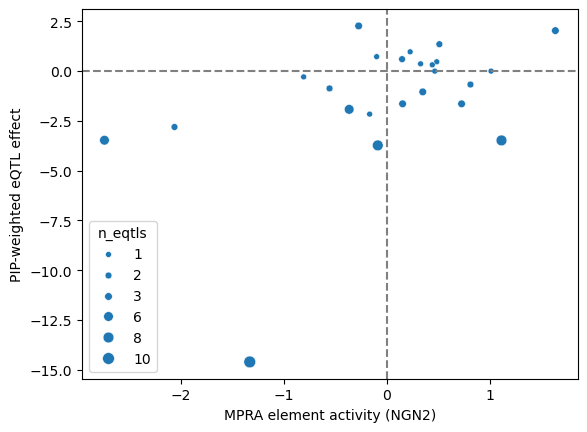

In [ ]:
sns.scatterplot(
    data=region_eqtl_summary_with_activity,
    x="normalized_activity_NGN2",
    y="pip_weighted_beta",
    size="n_eqtls",
)
plt.axhline(0, ls="--", c="grey")
plt.axvline(0, ls="--", c="grey")
plt.xlabel("MPRA element activity (NGN2)")
plt.ylabel("PIP-weighted eQTL effect")
plt.show()

In [ ]:
region_eqtl_summary_with_activity = region_eqtl_summary_with_activity.add_prefix(
    "brain_eQTL_"
).rename(columns={"brain_eQTL_normalized_name": "normalized_name"})
region_eqtl_summary_with_activity = region_eqtl_summary_with_activity[
    [
        "normalized_name",
        "brain_eQTL_gene_symbols",
        "brain_eQTL_n_eqtls",
        "brain_eQTL_mean_beta",
        "brain_eQTL_median_beta",
        "brain_eQTL_sum_beta",
        "brain_eQTL_pip_weighted_beta",
        "brain_eQTL_fraction_positive",
        "brain_eQTL_direction_consistency",
    ]
].copy()
region_eqtl_summary_with_activity["has_overlapping_brain_eQTL"] = True

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    region_eqtl_summary_with_activity, on="normalized_name", how="left"
)
mpra_80k_metadata_df_bcalm["has_overlapping_brain_eQTL"] = mpra_80k_metadata_df_bcalm[
    "has_overlapping_brain_eQTL"
].fillna(False)
print(
    f"Elements with an overlapping brain eQTL: {mpra_80k_metadata_df_bcalm['has_overlapping_brain_eQTL'].sum()}"
)

Elements with an overlapping brain eQTL: 24


/tmp/ipykernel_98414/3423116597.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False)


### TFBS composition with REMAP2022

In [ ]:
# NOTE: remap2022_nr_macs2_hg38_v1_0.bed.gz can be downloaded from ReMap2022 (https://remap.univ-amu.fr/download_page) was downloaded 15.05.2025

# awk 'BEGIN{OFS="\t"} {$NF=$NF; split($4,a,":"); print $0, a[1]}' <(zcat remap2022_nr_macs2_hg38_v1_0.bed.gz) | gzip > remap2022_nr_macs2_hg38_v1_0_target_column.bed.gz

# # sort the remap file:
# sort -k1,1 -k2,2n <( zcat remap2022_nr_macs2_hg38_v1_0_target_column.bed.gz ) | gzip > remap2022_nr_macs2_hg38_v1_0_target_column_sorted.bed.gz

# bedtools intersect -a /sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/mpra_80k_unique_regions.bed -b /sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_remap2022_overlap/remap2022_nr_macs2_hg38_v1_0_target_column_sorted.bed.gz -wo > 80k_mpra_CREs_remap2022.bed.gz
too_large_to_store = True
if too_large_to_store:
    # note 80k_mpra_CREs_remap2022.bed.gz is too large to be stored in the repo, use the code provided above to generate it
    remap2022_CRE_overlap_path = "data/remap_overlap/80k_mpra_CREs_remap2022.bed.gz"
    remap2022_CRE_overlap = pd.read_csv(remap2022_CRE_overlap_path, sep="\t", header=None, low_memory=False)
    remap2022_CRE_overlap.columns = ["chrom", "start", "end", "name", "chrom_B", "start_B", "end_B", "name_remap", "score_B", "strand_B", "peak_start", "peak_end", "spectrum", "TF_name", "overlap_number"]



    # investigate the size of the overlapping TFBS peaks
    remap2022_CRE_overlap["chip_peak_size"] = remap2022_CRE_overlap["end_B"] - remap2022_CRE_overlap["start_B"]

    CRE_LENGTH = 270
    remap2022_CRE_overlap["CRE_proportion_overlapped"] = round(remap2022_CRE_overlap["overlap_number"] / (CRE_LENGTH)*100, 2)


    remap2022_CRE_overlap_filtered_df = remap2022_CRE_overlap[
        (remap2022_CRE_overlap['peak_start'] >= remap2022_CRE_overlap['start'] + 5) &
        (remap2022_CRE_overlap['peak_end'] <= remap2022_CRE_overlap['end'] - 5)  &
        (remap2022_CRE_overlap['overlap_number'] >= 10)
    ]


    output_path = "data/all_80k_unique_regions_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz"
    writing = False
    if writing:
        remap2022_CRE_overlap_filtered_df.to_csv(output_path, sep="\t", index=False)

In [ ]:
remap_filtered_path = "data/all_80k_unique_regions_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz"
remap_filtered_df = pd.read_csv(remap_filtered_path, sep="\t", header=None, low_memory=False)
remap_filtered_df.columns = [
    "chrom",
    "start",
    "end",
    "name",
    "chrom_B",
    "start_B",
    "end_B",
    "name_remap",
    "score_B",
    "strand_B",
    "peak_start",
    "peak_end",
    "spectrum",
    "TF_name",
    "overlap_number",
    "chip_peak_size",
    "CRE_proportion_overlapped",
]

remap_tfbs_occurences = (
    remap_filtered_df.groupby(["chrom", "start", "end"])
    .agg(
        REMAP2022_TFBS_list=("TF_name", list),
        REMAP2022_number_of_TFBS=("TF_name", "count"),
    )
    .reset_index()
)
remap_tfbs_occurences["REMAP2022_n_unique_TFBS"] = remap_tfbs_occurences[
    "REMAP2022_TFBS_list"
].apply(lambda tfs: len(set(tfs)))

# a stray header row sometimes ends up as data in the filtered bed; drop it
remap_tfbs_occurences = remap_tfbs_occurences[remap_tfbs_occurences["start"] != "start"].copy()
remap_tfbs_occurences["start"] = remap_tfbs_occurences["start"].astype(int)
remap_tfbs_occurences["end"] = remap_tfbs_occurences["end"].astype(int)
remap_tfbs_occurences["region_info"] = remap_tfbs_occurences.apply(
    lambda row: generate_region_id(row, "chrom", "start", "end"), axis=1
)

remap_tfbs_columns = [
    "region_info",
    "REMAP2022_TFBS_list",
    "REMAP2022_number_of_TFBS",
    "REMAP2022_n_unique_TFBS",
]
remap_tfbs_occurences_unique = remap_tfbs_occurences[remap_tfbs_columns].drop_duplicates(
    subset=["region_info"]
)

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    remap_tfbs_occurences_unique, on="region_info", how="left"
)
mpra_80k_metadata_df_bcalm["REMAP2022_TFBS_list"] = mpra_80k_metadata_df_bcalm[
    "REMAP2022_TFBS_list"
].apply(lambda x: x if isinstance(x, list) else [])
mpra_80k_metadata_df_bcalm["REMAP2022_number_of_TFBS"] = (
    mpra_80k_metadata_df_bcalm["REMAP2022_number_of_TFBS"].fillna(0).astype(int)
)
mpra_80k_metadata_df_bcalm["REMAP2022_n_unique_TFBS"] = (
    mpra_80k_metadata_df_bcalm["REMAP2022_n_unique_TFBS"].fillna(0).astype(int)
)
print(
    f"Elements with a REMAP2022 TFBS overlap: {(mpra_80k_metadata_df_bcalm['REMAP2022_number_of_TFBS'] > 0).sum()}"
)

Elements with a REMAP2022 TFBS overlap: 74733


### PhastCons score

In [ ]:
phastCons_average_tab_path = "data/all_tested_CRE_phastCons100way.tab.gz"
phastCons_tested_CRE_df = pd.read_csv(
    phastCons_average_tab_path, sep="\t", low_memory=False, header=None
)
phastCons_tested_CRE_df.columns = [
    "name",
    "phastCons_seq_size",
    "phastCons_covered_size",
    "phastCons_sum",
    "phastCons_mean0",
    "phastCons_mean",
]
# only elements fully covered by the phastCons track (270 bp, the MPRA element length) get a score
phastCons_tested_CRE_df_fully_covered = phastCons_tested_CRE_df.loc[
    phastCons_tested_CRE_df["phastCons_covered_size"] == 270
].copy()
phast_cons_columns = ["name", "phastCons_sum", "phastCons_mean0", "phastCons_mean"]

mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    phastCons_tested_CRE_df_fully_covered[phast_cons_columns], on="name", how="left"
)

matched_phastCons_rows = (
    phastCons_tested_CRE_df_fully_covered[phast_cons_columns]
    .merge(mpra_80k_metadata_df_bcalm[["name"]], on="name", how="inner")
    .shape[0]
)
if matched_phastCons_rows != phastCons_tested_CRE_df_fully_covered.shape[0]:
    raise ValueError("phastCons merge dropped or duplicated rows unexpectedly.")

print(
    f"Elements with a phastCons score: {mpra_80k_metadata_df_bcalm['phastCons_sum'].notna().sum()}"
)

Elements with a phastCons score: 68114


### Singleton density

In [ ]:
# NOTE: see variant_based_analysis/data/generating_singleton_counts_gnomad.py for the code to generate the data
# bedtools intersect -a sorted_tested_genomic_SCREEN_regions_without_chr.bed -b sorted_singleton_variants.bed -c > CRE_singleton_overlaps_with_counts.bed

singleton_CRE_overlap_number_bed = "data/CRE_singleton_overlaps_with_counts.bed"
singleton_CRE_overlap_number = pd.read_csv(
    singleton_CRE_overlap_number_bed, sep="\t", header=None
)
singleton_CRE_overlap_number.columns = [
    "chrom_no_chr",
    "start",
    "end",
    "SCREEN_ID",
    "singleton_overlap_count",
]

mpra_80k_metadata_df_bcalm_with_region = mpra_80k_metadata_df_bcalm.loc[
    mpra_80k_metadata_df_bcalm["start"].notna()
].copy()
mpra_80k_metadata_df_bcalm_with_region["start"] = mpra_80k_metadata_df_bcalm_with_region[
    "start"
].astype(int)
mpra_80k_metadata_df_bcalm_with_region["end"] = mpra_80k_metadata_df_bcalm_with_region[
    "end"
].astype(int)
mpra_80k_metadata_df_bcalm_with_region["chrom_no_chr"] = mpra_80k_metadata_df_bcalm_with_region[
    "chr"
].str.replace("chr", "")

singleton_overlap_by_name = mpra_80k_metadata_df_bcalm_with_region[
    ["name", "chrom_no_chr", "start", "end"]
].merge(
    singleton_CRE_overlap_number[["chrom_no_chr", "start", "end", "singleton_overlap_count"]],
    on=["chrom_no_chr", "start", "end"],
    how="left",
)
mpra_80k_metadata_df_bcalm = mpra_80k_metadata_df_bcalm.merge(
    singleton_overlap_by_name[["name", "singleton_overlap_count"]], on="name", how="left"
)
print(
    "Elements missing singleton overlap info (controls without genomic coords): "
    f"{mpra_80k_metadata_df_bcalm['singleton_overlap_count'].isna().sum()}"
)

Elements missing singleton overlap info (controls without genomic coords): 6275


### Write to file

In [ ]:
full_element_annotation_output_path = "data/all_80k_MPRA_elements_annotations_table_2606_eQTL_phastCons_ReMap.tsv.gz"
if writing:
    mpra_80k_metadata_df_bcalm.to_csv(full_element_annotation_output_path, sep="\t", index=False)
    print(f"Wrote full element annotation table to {full_element_annotation_output_path}")

mpra_80k_metadata_df_bcalm_tested_ref = mpra_80k_metadata_df_bcalm.loc[
    mpra_80k_metadata_df_bcalm["name"].str.contains("cardiac_neuro_cava_random:")
    & ~mpra_80k_metadata_df_bcalm["name"].str.contains(":ALT_")
    & mpra_80k_metadata_df_bcalm["normalized_activity_NGN2"].notna()
].copy()

tested_ref_element_annotation_output_path = "data/2606_ref_element_annotation_n_24510.tsv.gz"
if writing:
    mpra_80k_metadata_df_bcalm_tested_ref.to_csv(
        tested_ref_element_annotation_output_path, sep="\t", index=False
    )
    print(
        f"Wrote tested reference-only element annotation table to {tested_ref_element_annotation_output_path}"
    )

## QC: sanity checks on the built table

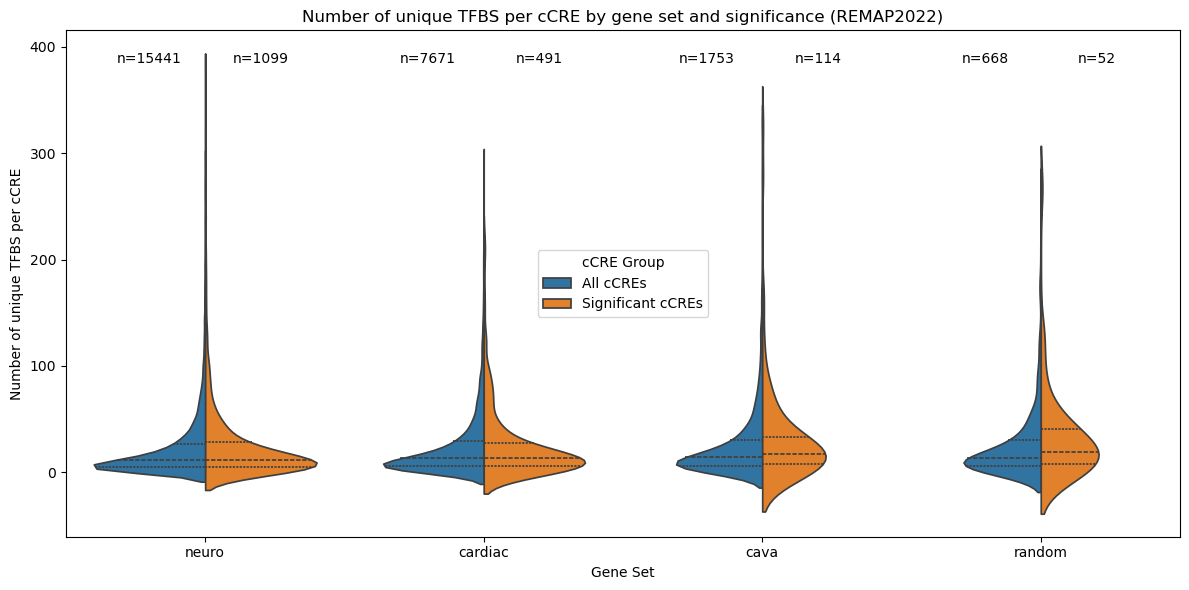

In [ ]:
def plotting_violin_side_by_side_sig_not_column(
    df, gene_set_col, value_col, sig_col, title="Violin Plot", xlabel="Gene Set", ylabel="Value"
):
    """Violin plot comparing all vs. significantly active cCREs, split by gene set."""
    df_expl = df.explode(gene_set_col).copy()
    df_expl[gene_set_col] = df_expl[gene_set_col].astype(str)

    all_cre = df_expl[[gene_set_col, value_col]].rename(
        columns={gene_set_col: "Gene_Set", value_col: "Value"}
    )
    all_cre["cCRE Group"] = "All cCREs"
    sig_cre = df_expl.loc[df_expl[sig_col], [gene_set_col, value_col]].rename(
        columns={gene_set_col: "Gene_Set", value_col: "Value"}
    )
    sig_cre["cCRE Group"] = "Significant cCREs"
    final_plot_data = pd.concat([all_cre, sig_cre], ignore_index=True)
    gene_set_order = ["neuro", "cardiac", "cava", "random"]
    final_plot_data["Gene_Set"] = pd.Categorical(
        final_plot_data["Gene_Set"], categories=gene_set_order, ordered=True
    )

    summary_data = (
        df_expl.groupby(gene_set_col)
        .agg(All_Count=(value_col, "count"), Significant_Count=(sig_col, "sum"))
        .reset_index()
        .rename(columns={gene_set_col: "Gene_Set"})
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        x="Gene_Set", y="Value", hue="cCRE Group", data=final_plot_data, split=True, inner="quart", ax=ax
    )

    x_positions = {cat: i for i, cat in enumerate(t.get_text() for t in ax.get_xticklabels())}
    bar_width = 0.4
    for gene_set in summary_data["Gene_Set"]:
        xpos = x_positions.get(gene_set)
        if xpos is None:
            continue
        all_count = summary_data.loc[summary_data["Gene_Set"] == gene_set, "All_Count"].iloc[0]
        sig_count = summary_data.loc[
            summary_data["Gene_Set"] == gene_set, "Significant_Count"
        ].iloc[0]
        ax.text(xpos - bar_width / 2, ax.get_ylim()[1] * 0.95, f"n={all_count}", ha="center", va="top", fontsize=10)
        if sig_count > 0:
            ax.text(
                xpos + bar_width / 2, ax.get_ylim()[1] * 0.95, f"n={sig_count}", ha="center", va="top", fontsize=10
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


mpra_80k_metadata_df_bcalm_tested_ref_all = mpra_80k_metadata_df_bcalm_tested_ref.copy()

plotting_violin_side_by_side_sig_not_column(
    df=mpra_80k_metadata_df_bcalm_tested_ref_all,
    gene_set_col="gene_set",
    value_col="REMAP2022_n_unique_TFBS",
    sig_col="significant_region_NGN2",
    title="Number of unique TFBS per cCRE by gene set and significance (REMAP2022)",
    xlabel="Gene Set",
    ylabel="Number of unique TFBS per cCRE",
)

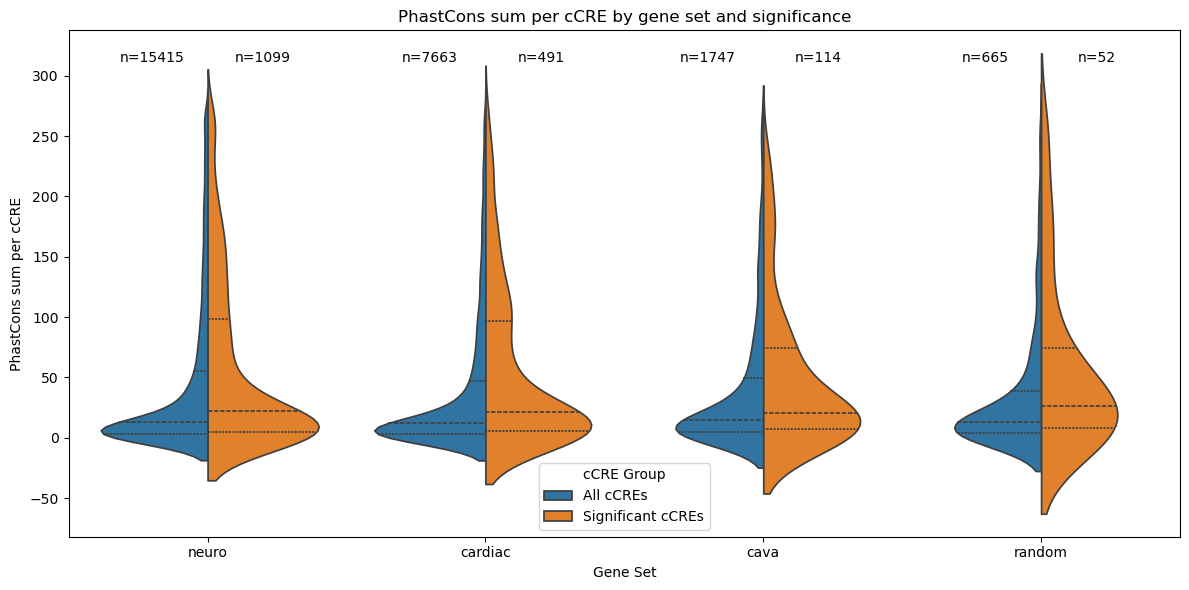

In [ ]:
plotting_violin_side_by_side_sig_not_column(
    df=mpra_80k_metadata_df_bcalm_tested_ref_all,
    gene_set_col="gene_set",
    value_col="phastCons_sum",
    sig_col="significant_region_NGN2",
    title="PhastCons sum per cCRE by gene set and significance",
    xlabel="Gene Set",
    ylabel="PhastCons sum per cCRE",
)

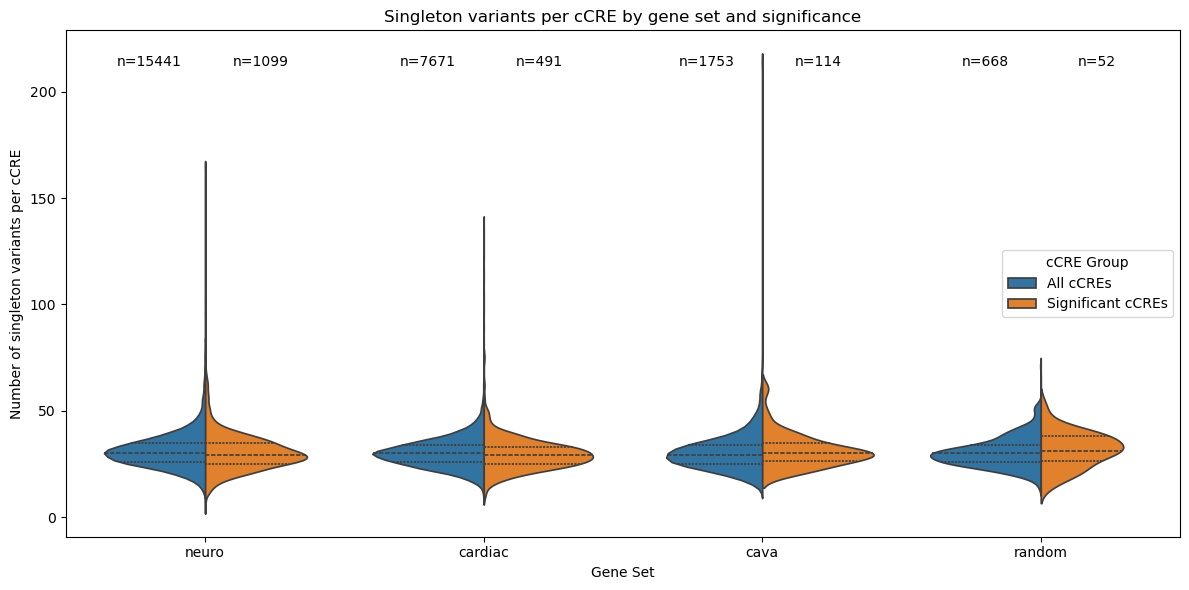

In [ ]:
plotting_violin_side_by_side_sig_not_column(
    df=mpra_80k_metadata_df_bcalm_tested_ref_all,
    gene_set_col="gene_set",
    value_col="singleton_overlap_count",
    sig_col="significant_region_NGN2",
    title="Singleton variants per cCRE by gene set and significance",
    xlabel="Gene Set",
    ylabel="Number of singleton variants per cCRE",
)

### Brain SCREEN cCRE vs non-brain cCRE activity difference

n brain cCREs: 7583, n non-brain cCREs: 16927
Mann-Whitney U statistic: 69001142.0, p-value: 4.591906512883878e-21
Cliff's delta: 0.0751


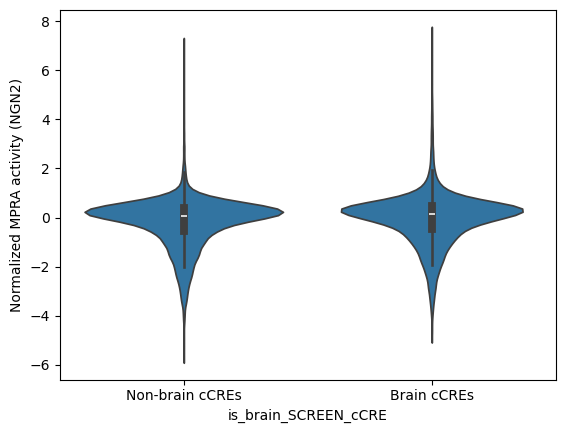

In [ ]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x) * len(y))


brain_cCRE_activity = mpra_80k_metadata_df_bcalm_tested_ref_all.loc[
    mpra_80k_metadata_df_bcalm_tested_ref_all["is_brain_SCREEN_cCRE"], "normalized_activity_NGN2"
]
non_brain_cCRE_activity = mpra_80k_metadata_df_bcalm_tested_ref_all.loc[
    ~mpra_80k_metadata_df_bcalm_tested_ref_all["is_brain_SCREEN_cCRE"], "normalized_activity_NGN2"
]
print(f"n brain cCREs: {len(brain_cCRE_activity)}, n non-brain cCREs: {len(non_brain_cCRE_activity)}")

stat, p_value = mannwhitneyu(brain_cCRE_activity, non_brain_cCRE_activity, alternative="two-sided")
delta = cliffs_delta(brain_cCRE_activity, non_brain_cCRE_activity)
print(f"Mann-Whitney U statistic: {stat}, p-value: {p_value}")
print(f"Cliff's delta: {delta:.4f}")

sns.violinplot(
    data=mpra_80k_metadata_df_bcalm_tested_ref_all, x="is_brain_SCREEN_cCRE", y="normalized_activity_NGN2"
)
plt.xticks([0, 1], ["Non-brain cCREs", "Brain cCREs"])
plt.ylabel("Normalized MPRA activity (NGN2)")
plt.show()

n significant brain cCREs: 580, n significant non-brain cCREs: 1108
Mann-Whitney U statistic (significant only): 403479.0, p-value: 5.6895558037872665e-18
Cliff's delta (significant only): 0.2557


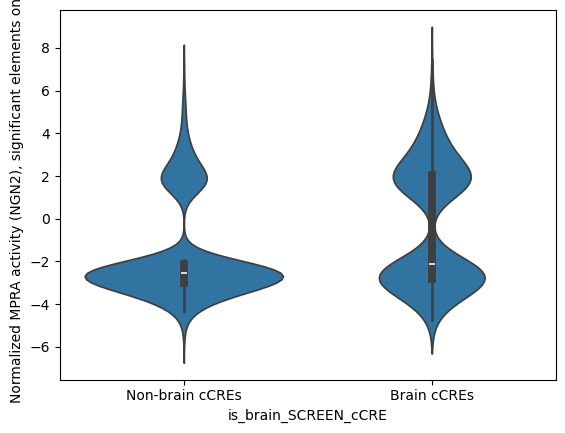

In [ ]:
mpra_80k_metadata_df_bcalm_tested_ref_significant = mpra_80k_metadata_df_bcalm_tested_ref_all.loc[
    mpra_80k_metadata_df_bcalm_tested_ref_all["significant_region_NGN2"]
].copy()

brain_cCRE_activity_sig = mpra_80k_metadata_df_bcalm_tested_ref_significant.loc[
    mpra_80k_metadata_df_bcalm_tested_ref_significant["is_brain_SCREEN_cCRE"],
    "normalized_activity_NGN2",
]
non_brain_cCRE_activity_sig = mpra_80k_metadata_df_bcalm_tested_ref_significant.loc[
    ~mpra_80k_metadata_df_bcalm_tested_ref_significant["is_brain_SCREEN_cCRE"],
    "normalized_activity_NGN2",
]
print(
    f"n significant brain cCREs: {len(brain_cCRE_activity_sig)}, "
    f"n significant non-brain cCREs: {len(non_brain_cCRE_activity_sig)}"
)

stat_sig, p_value_sig = mannwhitneyu(
    brain_cCRE_activity_sig, non_brain_cCRE_activity_sig, alternative="two-sided"
)
delta_sig = cliffs_delta(brain_cCRE_activity_sig, non_brain_cCRE_activity_sig)
print(f"Mann-Whitney U statistic (significant only): {stat_sig}, p-value: {p_value_sig}")
print(f"Cliff's delta (significant only): {delta_sig:.4f}")

sns.violinplot(
    data=mpra_80k_metadata_df_bcalm_tested_ref_significant,
    x="is_brain_SCREEN_cCRE",
    y="normalized_activity_NGN2",
)
plt.xticks([0, 1], ["Non-brain cCREs", "Brain cCREs"])
plt.ylabel("Normalized MPRA activity (NGN2), significant elements only")
plt.show()